# ML Pipeline
## Phase 1: Setup and Data Preperation
Load data, select right features for the model, ensure datas are in usable format. Handle Categorical Data. Scale the data

## Phase 2: Unsupervised Learning - Discovering Grip Strategies
Use the kinematic data to find natural groupings, which we will interpret as different "grip strategies". Do PCA, K Means Clustering Algorithm. Each Cluster will represent a grip strategy. Then assign cluster labels to the original DataFrame. Now every trial is assigned a grip strategy.
 
## Phase 3: Interpretation and Visualisation
Visualise the clusters. Use Cross tabulation to see how the discovered grip strategy relate to the experimental conditions (distance, surface). Eg. Strategy 0 is dominantly use for far distance and Strategy 1 is use for near distance.


## Phase 4: Supervised Learning
To build a machine learning model that can predict the experimental condition (like distance: near, middle, far) based solely on kinematic data (how the hand moved).

Goal: first, discover aiming strategies (unsupervised), then see if we can predict a condition like distance from the aiming kinematics (supervised).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score

In [3]:
df_aiming = pd.read_csv("C:/CourseWork/Dissertation Classifying grip strategies using machine learning/data/02_processed/aiming_master_dataset.csv")

print("Aiming Dataset loaded successfully")
print(f"Dateset shape: {df_aiming.shape}")

Aiming Dataset loaded successfully
Dateset shape: (2423, 213)


In [4]:
# Cleanup columns
df_aiming = df_aiming.drop(columns=["DOB", "Gender", "Dominant.Eye"], errors="ignore")

In [5]:
# Feature Selection
identifier_cols = ["subjName", "trialN"]
condition_cols = ["visCond", "surface", "distance"]

kinematic_features = df_aiming.select_dtypes(include=np.number).columns.tolist()
kinematic_features = [col for col in kinematic_features if col not in identifier_cols]

print(f"\nIdentified {len(kinematic_features)} kinematic features")

# Scaling Kinematic Features
X_kinematic = df_aiming[kinematic_features].copy()

# Handle any potential missing values 
if X_kinematic.isnull().sum().sum() > 0:
    print("\nWarning: Missing values detected. Filling with the mean")
    X_kinematic = X_kinematic.fillna(X_kinematic.mean())

# Scaling
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X_kinematic)
print("\nKinematic features have been scaled")


Identified 205 kinematic features

Kinematic features have been scaled


# Phase 2: Unsupervised Learning

In [6]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA reduced dimensions to {pca.n_components_} components, explaining {np.sum(pca.explained_variance_ratio_):.2f}% of variance")

PCA reduced dimensions to 59 components, explaining 0.95% of variance


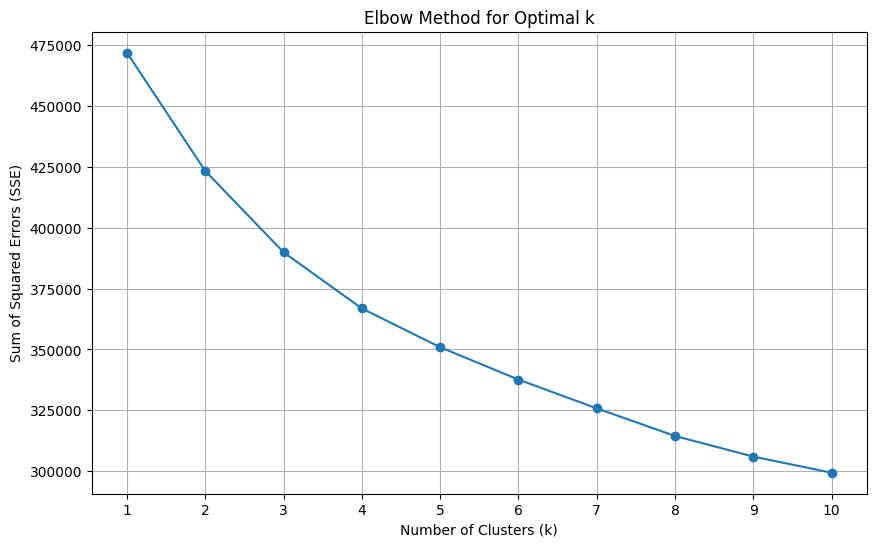

In [7]:
# Clusstering (K Means)
# FInd optimal number of k using Elbow Method
sse = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=123, n_init=10)
    kmeans.fit(X_pca)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [ ]:
# 2. Clustering (K Means)
optimal_k = 4
print(f"Based on this elbow plot, we will proceed with k={optimal_k} clusters")

# Apply K Means with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=123, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

# Assigning Strategy Labels
df_aiming["aiming_strategy"] = cluster_labels
print(f"Assigned trials to {optimal_k} grip strategies")

Based on this elbow plot, we will proceed with k=4 clusters
Assigned trials to 4 grip strategies


# Phase 3 Intepretation and Visualisation

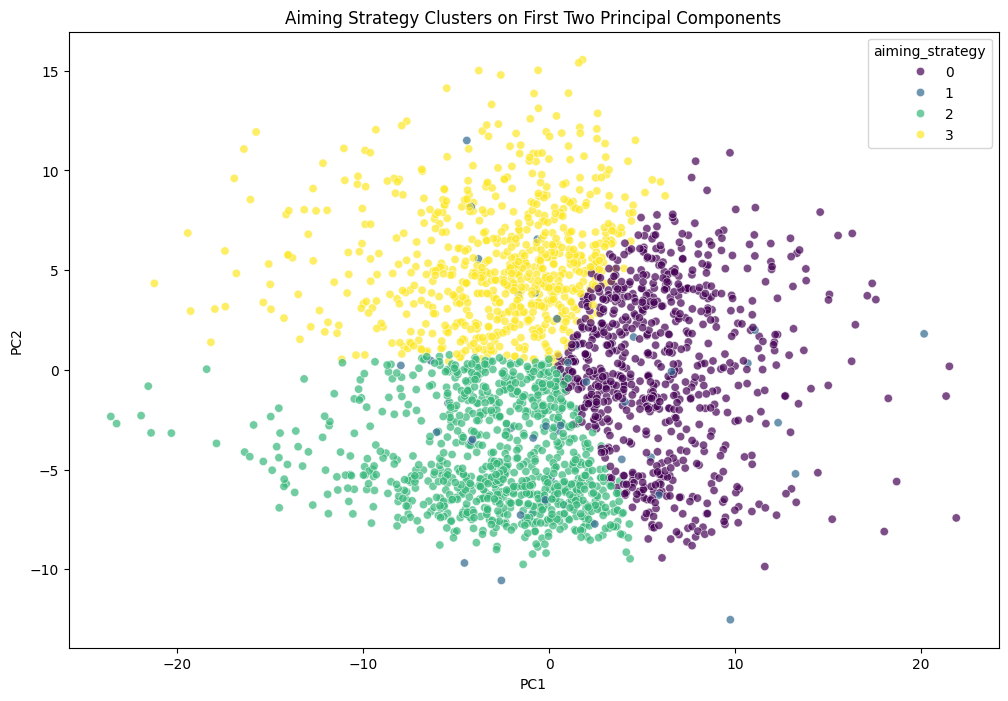

Relationship between aiming strategies and 'distance':
distance         one  three  two
aiming_strategy                 
0                155    278  302
1                 12     16   14
2                642      2  265
3                  1    512  224


In [ ]:
df_aiming["aiming_strategy"] = cluster_labels

# Visualise Clusters on PCA plot
pca_df = pd.DataFrame(data=X_pca[:, :2], columns=["PC1", "PC2"])
pca_df["aiming_strategy"] = cluster_labels

plt.figure(figsize=(12, 8))
sns.scatterplot(x="PC1", y="PC2", hue="aiming_strategy", data=pca_df, palette="viridis", alpha=0.7)
plt.title("Aiming Strategy Clusters on First Two Principal Components")
plt.show()

# Relate Strategies to Conditions
print("Relationship between aiming strategies and 'distance':")
print(pd.crosstab(df_aiming["aiming_strategy"], df_aiming["distance"]))


The PCA plot shows 4 clusters that are reasonably well-defined, though with more overlap than the prehension data. This is expected, as "aiming" might be a more continuous action than "grasping."

Aiming Strategy 0 (The "General-Purpose Aim"): This strategy is used across all distances, making it a versatile, "all-rounder" aiming movement. It's the most common strategy for the middle (two) and far (three) distances.

Aiming Strategy 1 (The "Anomalous Movement"): This cluster contains very few trials (12, 16, 14). This is an outlier cluster. It likely represents trials with tracking errors, subject mistakes, or simply highly unusual, non-standard movements that don't fit the main patterns.

Aiming Strategy 2 (The "Short-Range Point"): This is the most unambiguous strategy. It is used overwhelmingly for distance one (642 trials) and two (265 trials), and almost never for three. This is the primary strategy for close-range aiming.

Aiming Strategy 3 (The "Long-Range Lunge"): This strategy is the clear counterpart to strategy 2. It's used predominantly for distance three (512 trials) and two (224 trials), and essentially never for one. This is the strategy for far-range aiming.

# Phase 4: Supervised Learning 


Cross Validation accracy scores for predicting distance: [1.         0.99455535 0.9978903  0.99530516 0.99765258]
Mean CV Accuracy: 0.9971 (+/- 0.0020)


C:\Users\bharg\AppData\Local\Temp\ipykernel_64804\3194073633.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')


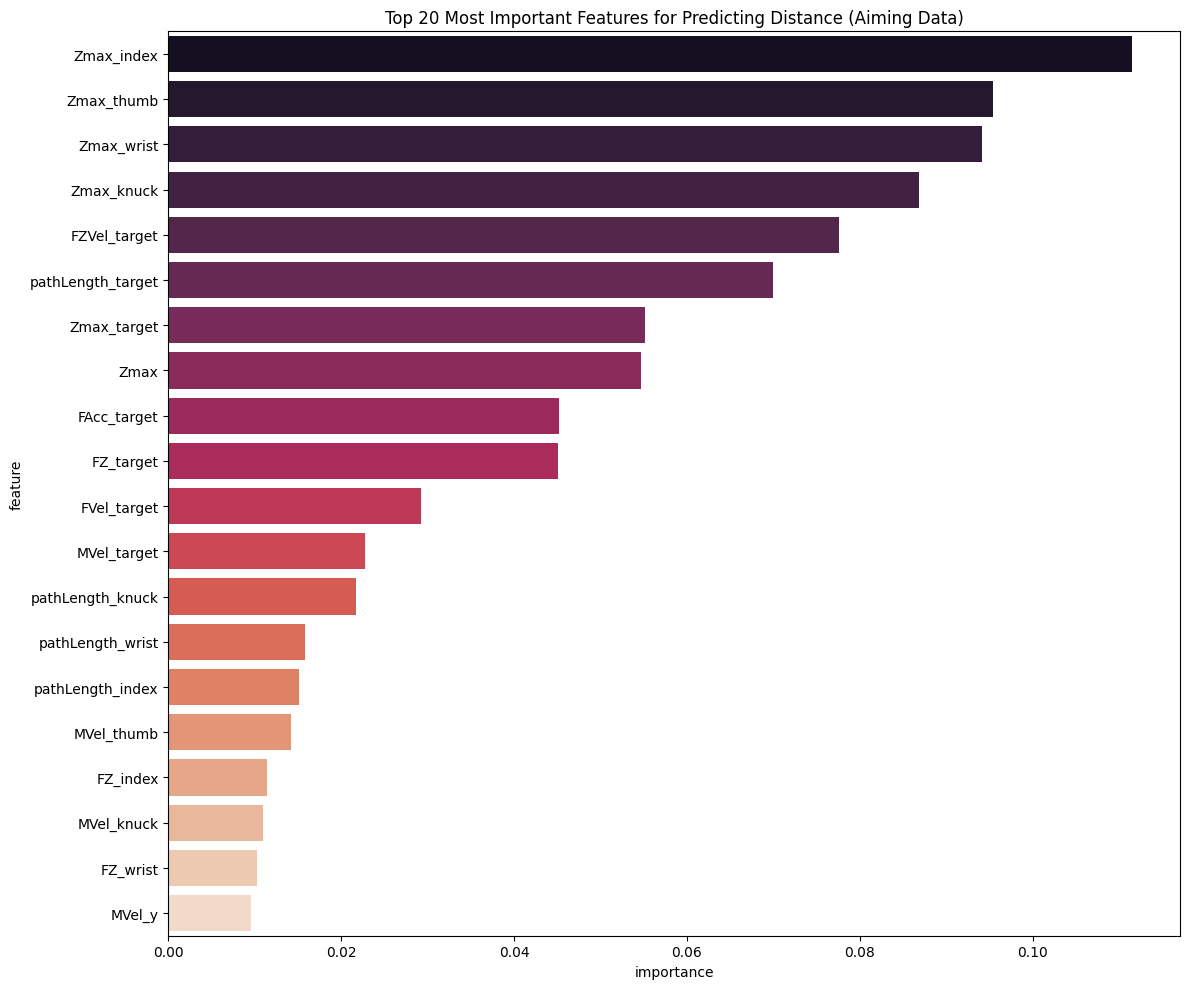

In [12]:
# Problem Formulation
X_supervised = df_aiming[kinematic_features]
y_supervised = df_aiming["distance"]

# Check if target variable exists
if y_supervised.isnull().all():
    print("Supervised target 'distance' not found or all null. Skipping supervised section.")
else:
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_supervised)

    # 2. Cross validation
    groups = df_aiming["subjName"]
    group_kfold = GroupKFold(n_splits=5)
    pipeline = Pipeline([
        ("scalar", StandardScaler()),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=123))
    ])
    cv_scores = cross_val_score(pipeline, X_supervised, y_encoded, cv=group_kfold, groups=groups)

    print(f"\nCross Validation accracy scores for predicting distance: {cv_scores}")
    print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

    # 3. Feature Importance
    pipeline.fit(X_supervised, y_encoded)
    importances = pipeline.named_steps['rf'].feature_importances_
    feature_importance_df = pd.DataFrame({
        'feature': kinematic_features,
        'importance': importances
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(12, 10))
    sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')
    plt.title('Top 20 Most Important Features for Predicting Distance (Aiming Data)')
    plt.tight_layout()
    plt.show()

The feature importance plot for the aiming data tells almost the exact same story as the prehension data.

Dominant Features: The top 5 features are all related to the maximum forward position (Zmax_index, Zmax_thumb, Zmax_wrist, Zmax_knuck) or forward velocity (FZVel_target).

Interpretation: For both grasping and aiming, the most predictive kinematic variable for how far a subject intends to move is the maximum forward extent of their reach. This robustly confirms that the brain plans the endpoint of the movement as a primary variable. The model finds this signal to be far stronger than speed (MVel) or acceleration (FAcc) for this specific predictive task.